In [ ]:
#a
"""

The transmission function is given as:
q(u) = sin**2(alpha * u)

1) Identify the positions of the slits:
   The slits correspond to the points of maximum transmission where q(u) = 1.
   
   sin**2(alpha * u) = 1  =>  sin(alpha * u) = +/- 1
   
   This occurs when the argument of the sine function satisfies:
   alpha * u = pi/2 + k * pi   (where k is an integer)
   
   Solving for the slit positions (u_k):
   u_k = pi / (2 * alpha) + (k * pi) / alpha

2) Calculate the separation (d) between two adjacent slits:
   d = u_(k+1) - u_k
   d = [pi / (2 * alpha) + (k + 1) * pi / alpha] - [pi / (2 * alpha) + k * pi / alpha]
   d = pi / alpha

Therefore, the separation of the slits in terms of alpha is:
d = pi / alpha
"""

In [1]:
#b
import numpy as np

def q(u):
    alfa = np.pi/(20e-6)
    return np.sin(alfa*u)**2



In [2]:
#c
import numpy as np

# parameters
number_of_slit = 10
d = 20e-6
w = 10 * d
lambda0 = 500e-9
f = 1
screen_width = 0.1


# integrand
def integrand(u,x):
    permeability = np.sqrt(q(u))
    exp = np.exp(1j*(2*np.pi)*x*u/(lambda0*f))
    return permeability * exp




# integral
def simpson_rule_integral(x):
    N = 500
    b = w/2
    a = -w/2
    h = (b-a)/N
    s = integrand(a,x) + integrand(b,x)
    for k in range(1,int(N/2)+1):
        s += 4*integrand(a+(2*k-1)*h,x)
    for k in range(1,int(N/2)):
        s += 2*integrand(a+2*k*h,x)
    integral_result = h*s/3
    intensity = abs(integral_result)**2
    return intensity

# lists
intensities = []
x_values = np.linspace(-0.05,0.05,500)
for x in x_values:
    light_intensity = simpson_rule_integral(x)
    intensities.append(light_intensity)






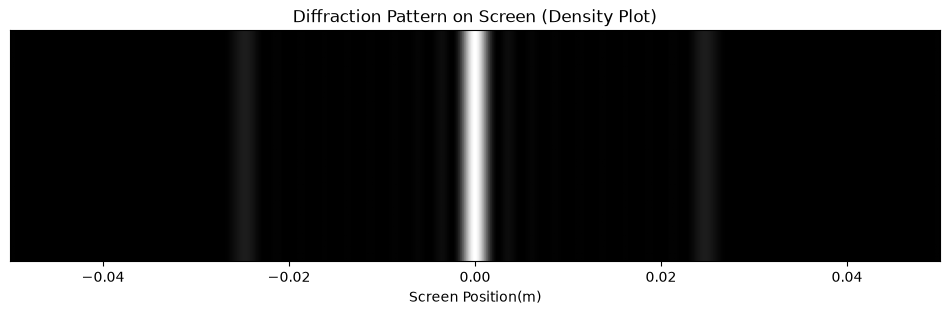

In [3]:
#d
import pylab as plt

intensities_arr = np.array(intensities)
matrix = np.tile(intensities_arr,(100,1))


# graph
plt.figure(figsize=(12,3)) # screen size
plt.imshow(matrix,cmap='gray',extent=[-0.05,0.05,0,1],aspect='auto') # cmap:color palette,  extent: x and y limit, aspect: Automatically adjusts the aspect ratio.
plt.yticks([]) # Hides the numbers and lines on the Y-axis to make the visual look cleaner.
plt.xlabel('Screen Position(m)')
plt.title('Diffraction Pattern on Screen (Density Plot)')
plt.show()


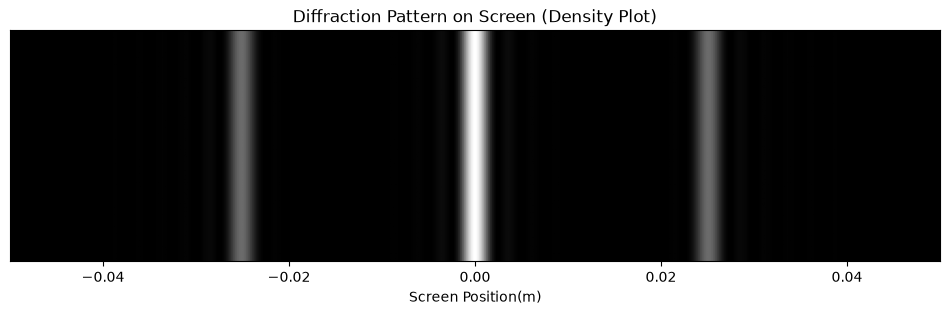

In [6]:
#e
def q(u):
    d = 20e-6
    val = u%d
    return np.where((val < 5e-6) | (val > 15e-6), 1.0, 0.0)  # Returns 1.0 if the condition is true, and 0.0 if it is false.


# parameters
number_of_slit = 10
d = 20e-6
w = 10 * d
lambda0 = 500e-9
f = 1
screen_width = 0.1


# integrand
def integrand(u,x):
    permeability = np.sqrt(q(u))
    exp = np.exp(1j*(2*np.pi)*x*u/(lambda0*f))
    return permeability * exp




# integral
def simpson_rule_integral(x):
    N = 500
    b = w/2
    a = -w/2
    h = (b-a)/N
    s = integrand(a,x) + integrand(b,x)
    for k in range(1,int(N/2)+1):
        s += 4*integrand(a+(2*k-1)*h,x)
    for k in range(1,int(N/2)):
        s += 2*integrand(a+2*k*h,x)
    integral_result = h*s/3
    intensity = abs(integral_result)**2
    return intensity

# lists
intensities = []
x_values = np.linspace(-0.05,0.05,500)
for x in x_values:
    light_intensity = simpson_rule_integral(x)
    intensities.append(light_intensity)



intensities_arr = np.array(intensities)
matrix = np.tile(intensities_arr,(100,1))


# graph
plt.figure(figsize=(12,3)) # screen size
plt.imshow(matrix,cmap='gray',extent=[-0.05,0.05,0,1],aspect='auto') # cmap:color palette,  extent: x and y limit, aspect: Automatically adjusts the aspect ratio.
plt.yticks([]) # Hides the numbers and lines on the Y-axis to make the visual look cleaner.
plt.xlabel('Screen Position(m)')
plt.title('Diffraction Pattern on Screen (Density Plot)')
plt.show()
